# FailBench v9 Dataset Analysis

Comprehensive visualization of the v9 dataset: cameras, depth, contacts, and distribution statistics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from pathlib import Path
import mujoco

from planner.experiments.data_capture import ContactProjector

DATASET_DIR = Path("scenes/scene_level2/datasets/v9")
SCENE_XML = "scenes/scene_level2/scene.xml"

manifest = pd.read_csv(DATASET_DIR / "manifest.csv")
print(f"Dataset: {len(manifest)} samples")
print(f"Columns: {list(manifest.columns)}")

Dataset: 40 samples
Columns: ['experiment_id', 'trajectory_file', 'seed', 'fail_phase', 'fail_step', 'num_contacts', 'num_failure_modes', 'had_any_collision', 'impacted_geom_ids', 'pre_qvel_norm', 'npz_file']


## 1. Dataset Overview

In [2]:
# Load all samples
samples = []
for _, row in manifest.iterrows():
    d = dict(np.load(DATASET_DIR / row['npz_file'], allow_pickle=True))
    d['_meta'] = row
    samples.append(d)

print(f"Loaded {len(samples)} samples")
print(f"\nKeys per sample: {sorted(samples[0].keys() - {'_meta'})}")
print(f"\nImage resolution: {samples[0]['pre_rgb'].shape}")
print(f"Contact counts: min={manifest['num_contacts'].min()}, "
      f"max={manifest['num_contacts'].max()}, "
      f"mean={manifest['num_contacts'].mean():.0f}")

Loaded 40 samples

Keys per sample: ['contact_failure_id', 'contact_forces', 'contact_geom_pairs', 'contact_positions', 'ee_cam_depth', 'ee_cam_rgb', 'fail_phase', 'fail_step', 'failure_modes', 'failure_probs', 'impacted_geom_ids', 'post_rgb', 'pre_depth', 'pre_ee_pos', 'pre_gripper_ctrl', 'pre_qpos', 'pre_qvel', 'pre_qvel_norm', 'pre_rgb', 'seed']

Image resolution: (480, 640, 3)
Contact counts: min=8000, max=22525, mean=10476


## 2. Single Sample Deep Dive

RGB + Depth from both cameras, pre- and post-failure.

In [3]:
# Pick a sample with many contacts
idx = manifest['num_contacts'].idxmax()
s = samples[idx]
meta = s['_meta']

print(f"Sample: {meta['experiment_id']}")
print(f"  Trajectory: {meta['trajectory_file']}")
print(f"  Seed: {meta['seed']}, Phase: {meta['fail_phase']}, Step: {meta['fail_step']}")
print(f"  Failure mode: {s['failure_modes'][0]}")
print(f"  |qvel| at failure: {s['pre_qvel_norm'][0]:.3f} rad/s")
print(f"  Contacts: {len(s['contact_positions']):,}")
print(f"  EE position: {s['pre_ee_pos']}")
print(f"  Joint positions: {np.array2string(s['pre_qpos'], precision=3)}")
print(f"  Joint velocities: {np.array2string(s['pre_qvel'], precision=3)}")

Sample: exp_00035
  Trajectory: scene_level2_RRTConnect_sample_7.pkl
  Seed: 35, Phase: 7, Step: 25
  Failure mode: single_joint
  |qvel| at failure: 1.694 rad/s
  Contacts: 22,525
  EE position: [-0.04103229 -0.28037183  0.53922341]
  Joint positions: [ 0.959  0.815 -2.861 -2.197  0.149  1.349 -1.198]
  Joint velocities: [ 0.01  -1.38   0.085  0.51  -0.667  0.465 -0.197]


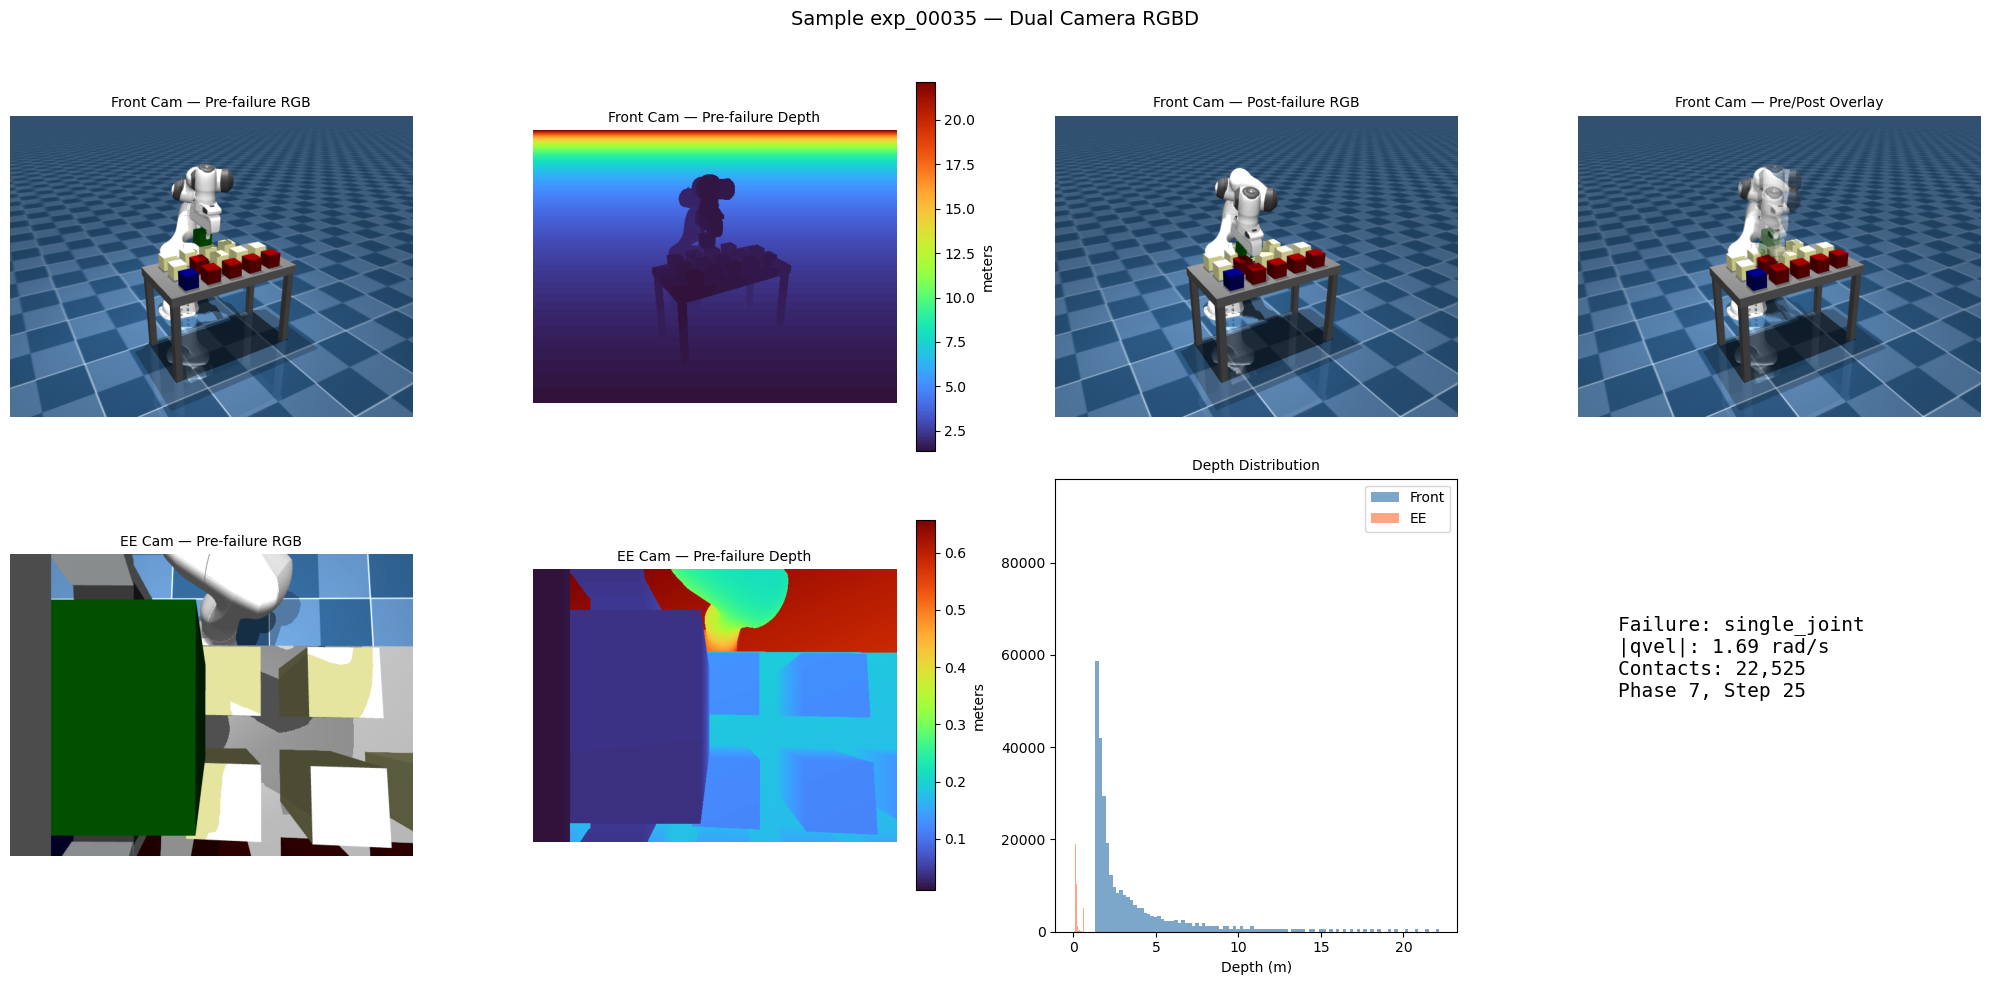

In [4]:
# --- RGB + Depth: Front cam and EE cam, pre- and post-failure ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Front cam
axes[0, 0].imshow(s['pre_rgb'])
axes[0, 0].set_title('Front Cam — Pre-failure RGB', fontsize=10)
axes[0, 0].axis('off')

depth_front = s['pre_depth']
im_fd = axes[0, 1].imshow(depth_front, cmap='turbo')
axes[0, 1].set_title('Front Cam — Pre-failure Depth', fontsize=10)
axes[0, 1].axis('off')
plt.colorbar(im_fd, ax=axes[0, 1], fraction=0.046, label='meters')

axes[0, 2].imshow(s['post_rgb'])
axes[0, 2].set_title('Front Cam — Post-failure RGB', fontsize=10)
axes[0, 2].axis('off')

# Depth difference (post not available as depth, show pre again with annotation)
axes[0, 3].imshow(s['pre_rgb'])
axes[0, 3].imshow(s['post_rgb'], alpha=0.5)
axes[0, 3].set_title('Front Cam — Pre/Post Overlay', fontsize=10)
axes[0, 3].axis('off')

# EE cam
axes[1, 0].imshow(s['ee_cam_rgb'])
axes[1, 0].set_title('EE Cam — Pre-failure RGB', fontsize=10)
axes[1, 0].axis('off')

depth_ee = s['ee_cam_depth']
im_ed = axes[1, 1].imshow(depth_ee, cmap='turbo')
axes[1, 1].set_title('EE Cam — Pre-failure Depth', fontsize=10)
axes[1, 1].axis('off')
plt.colorbar(im_ed, ax=axes[1, 1], fraction=0.046, label='meters')

# Depth histograms
valid_fd = depth_front[depth_front > 0].flatten()
valid_ed = depth_ee[depth_ee > 0].flatten()
axes[1, 2].hist(valid_fd, bins=100, alpha=0.7, label='Front', color='steelblue')
axes[1, 2].hist(valid_ed, bins=100, alpha=0.7, label='EE', color='coral')
axes[1, 2].set_title('Depth Distribution', fontsize=10)
axes[1, 2].set_xlabel('Depth (m)')
axes[1, 2].legend()

# Blank last cell — summary text
axes[1, 3].axis('off')
axes[1, 3].text(0.1, 0.7, f"Failure: {s['failure_modes'][0]}\n"
                f"|qvel|: {s['pre_qvel_norm'][0]:.2f} rad/s\n"
                f"Contacts: {len(s['contact_positions']):,}\n"
                f"Phase {meta['fail_phase']}, Step {meta['fail_step']}",
                fontsize=14, family='monospace', va='top',
                transform=axes[1, 3].transAxes)

plt.suptitle(f"Sample {meta['experiment_id']} — Dual Camera RGBD", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Contact Visualization

3D contact cloud colored by force magnitude, and 2D projection onto front camera.

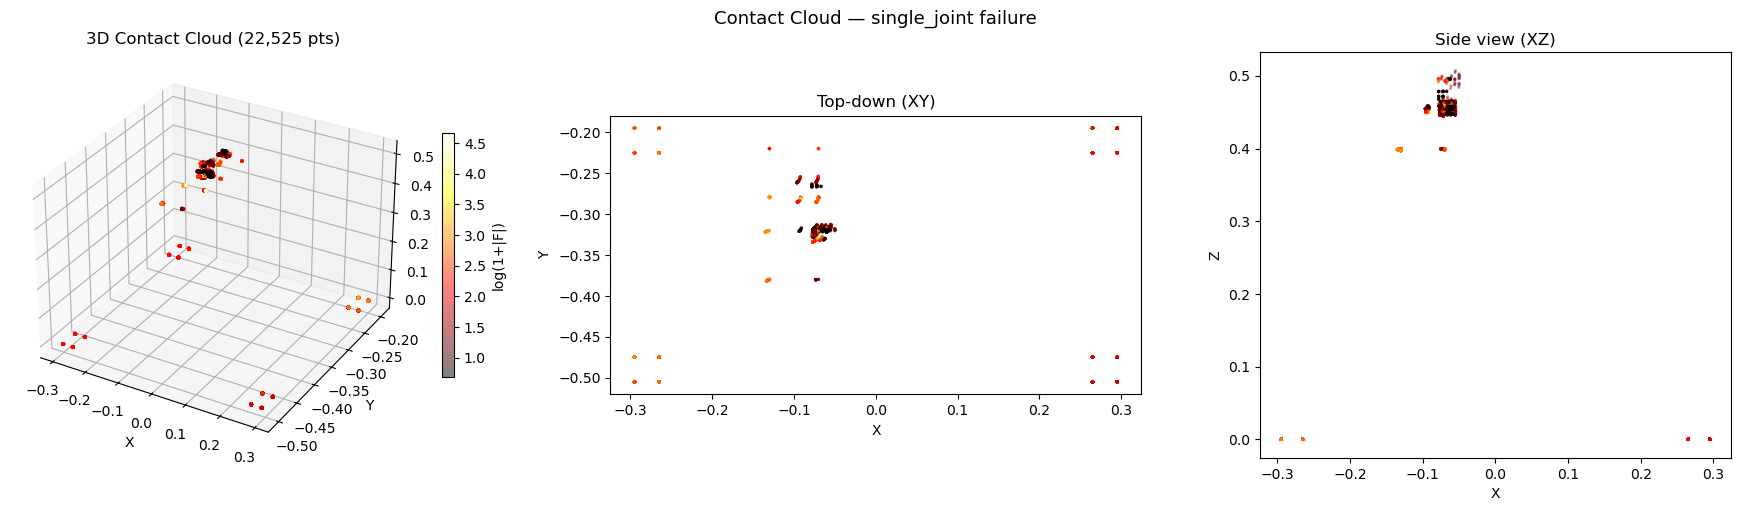

In [5]:
pos = s['contact_positions']
forces = s['contact_forces']
force_mag = np.linalg.norm(forces[:, :3], axis=1)
f_log = np.log1p(force_mag)

# Subsample for plotting
rng = np.random.default_rng(42)
if len(pos) > 5000:
    idx_sub = rng.choice(len(pos), 5000, replace=False)
    plot_pos, plot_f = pos[idx_sub], f_log[idx_sub]
else:
    plot_pos, plot_f = pos, f_log

fig = plt.figure(figsize=(18, 5))

# 3D scatter
ax1 = fig.add_subplot(131, projection='3d')
sc = ax1.scatter(plot_pos[:, 0], plot_pos[:, 1], plot_pos[:, 2],
                 c=plot_f, cmap='hot', s=3, alpha=0.5)
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_title(f'3D Contact Cloud ({len(pos):,} pts)')
plt.colorbar(sc, ax=ax1, shrink=0.6, label='log(1+|F|)')

# Top-down XY
ax2 = fig.add_subplot(132)
ax2.scatter(plot_pos[:, 0], plot_pos[:, 1], c=plot_f, cmap='hot', s=2, alpha=0.3)
ax2.set_xlabel('X'); ax2.set_ylabel('Y')
ax2.set_title('Top-down (XY)')
ax2.set_aspect('equal')

# Side view XZ
ax3 = fig.add_subplot(133)
ax3.scatter(plot_pos[:, 0], plot_pos[:, 2], c=plot_f, cmap='hot', s=2, alpha=0.3)
ax3.set_xlabel('X'); ax3.set_ylabel('Z')
ax3.set_title('Side view (XZ)')
ax3.set_aspect('equal')

plt.suptitle(f'Contact Cloud — {s["failure_modes"][0]} failure', fontsize=13)
plt.tight_layout()
plt.show()

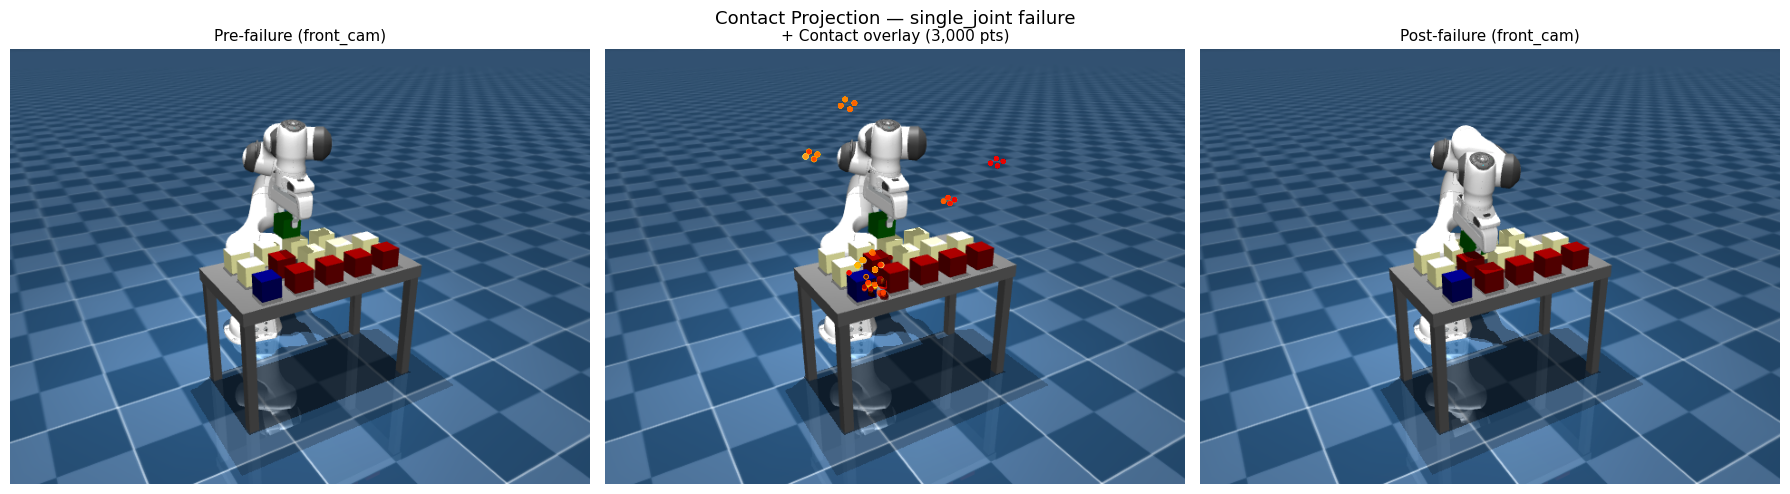

In [6]:
# --- Project contacts onto front camera image ---
model = mujoco.MjModel.from_xml_path(SCENE_XML)
projector = ContactProjector(model, camera_name='front_cam',
                             width=640, height=480)

px, depths = projector.project(pos)
in_frame = projector.in_frame(px, depths)

vis_px = px[in_frame]
vis_f = f_log[in_frame]

# Subsample
if len(vis_px) > 3000:
    idx_sub = rng.choice(len(vis_px), 3000, replace=False)
    vis_px, vis_f = vis_px[idx_sub], vis_f[idx_sub]

f_norm = vis_f / max(vis_f.max(), 1)
sizes = 2 + f_norm * 20

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pre-failure RGB
axes[0].imshow(s['pre_rgb'])
axes[0].set_title('Pre-failure (front_cam)', fontsize=11)
axes[0].axis('off')

# Pre-failure + contact overlay
axes[1].imshow(s['pre_rgb'])
axes[1].scatter(vis_px[:, 0], vis_px[:, 1], c=vis_f, cmap='hot',
                s=sizes, alpha=0.5, edgecolors='none')
axes[1].set_xlim(0, 640); axes[1].set_ylim(480, 0)
axes[1].set_title(f'+ Contact overlay ({len(vis_px):,} pts)', fontsize=11)
axes[1].axis('off')

# Post-failure RGB
axes[2].imshow(s['post_rgb'])
axes[2].set_title('Post-failure (front_cam)', fontsize=11)
axes[2].axis('off')

plt.suptitle(f'Contact Projection — {s["failure_modes"][0]} failure', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Force Analysis

Contact force magnitude distribution and geom pair breakdown.

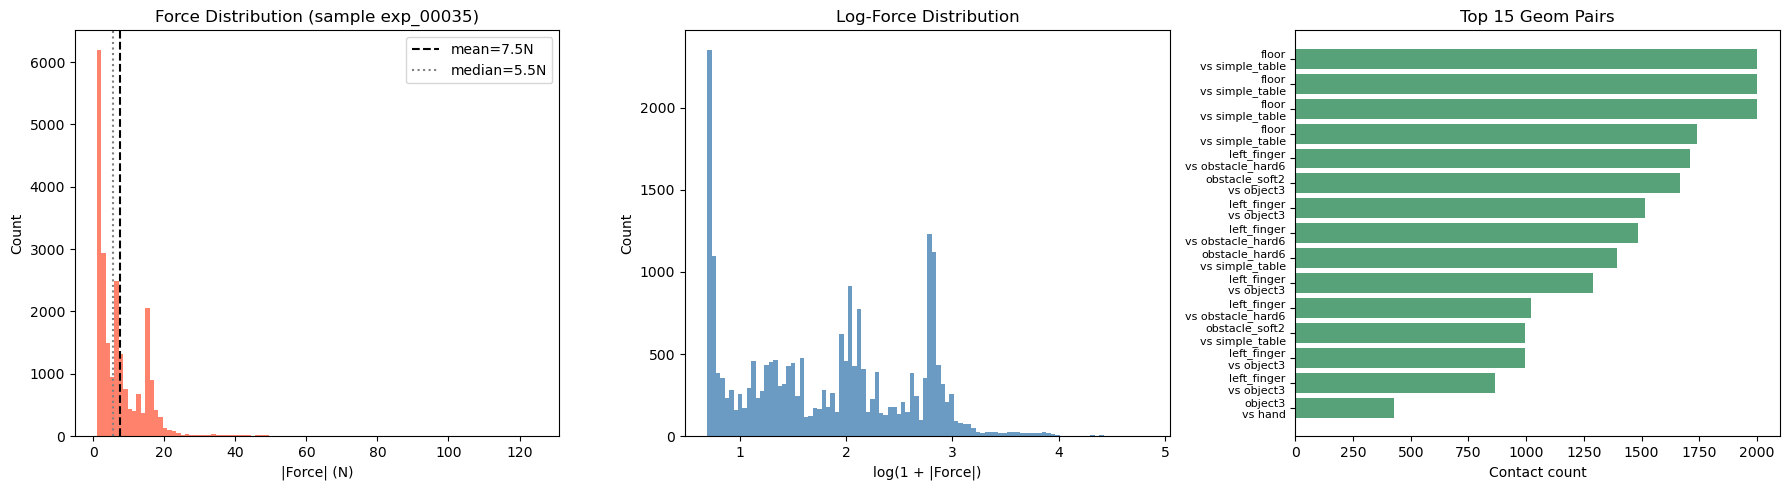

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Force magnitude histogram (this sample)
axes[0].hist(force_mag, bins=100, color='tomato', alpha=0.8, edgecolor='none')
axes[0].set_xlabel('|Force| (N)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Force Distribution (sample {meta["experiment_id"]})')
axes[0].axvline(force_mag.mean(), color='k', ls='--', label=f'mean={force_mag.mean():.1f}N')
axes[0].axvline(np.median(force_mag), color='gray', ls=':', label=f'median={np.median(force_mag):.1f}N')
axes[0].legend()

# Log-scale force histogram
axes[1].hist(f_log, bins=100, color='steelblue', alpha=0.8, edgecolor='none')
axes[1].set_xlabel('log(1 + |Force|)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-Force Distribution')

# Geom pair frequency
pairs = s['contact_geom_pairs']
unique_pairs, counts = np.unique(pairs, axis=0, return_counts=True)
top_k = min(15, len(unique_pairs))
top_idx = np.argsort(-counts)[:top_k]
labels = [f'({p[0]},{p[1]})' for p in unique_pairs[top_idx]]

# Resolve geom names where possible
try:
    resolved = []
    for p in unique_pairs[top_idx]:
        n1 = projector.geom_name(int(p[0]))
        n2 = projector.geom_name(int(p[1]))
        resolved.append(f'{n1}\nvs {n2}')
    labels = resolved
except:
    pass

axes[2].barh(range(top_k), counts[top_idx], color='seagreen', alpha=0.8)
axes[2].set_yticks(range(top_k))
axes[2].set_yticklabels(labels, fontsize=8)
axes[2].set_xlabel('Contact count')
axes[2].set_title(f'Top {top_k} Geom Pairs')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Dataset Distribution

Failure modes, trajectory fractions, velocity distribution across all 40 samples.

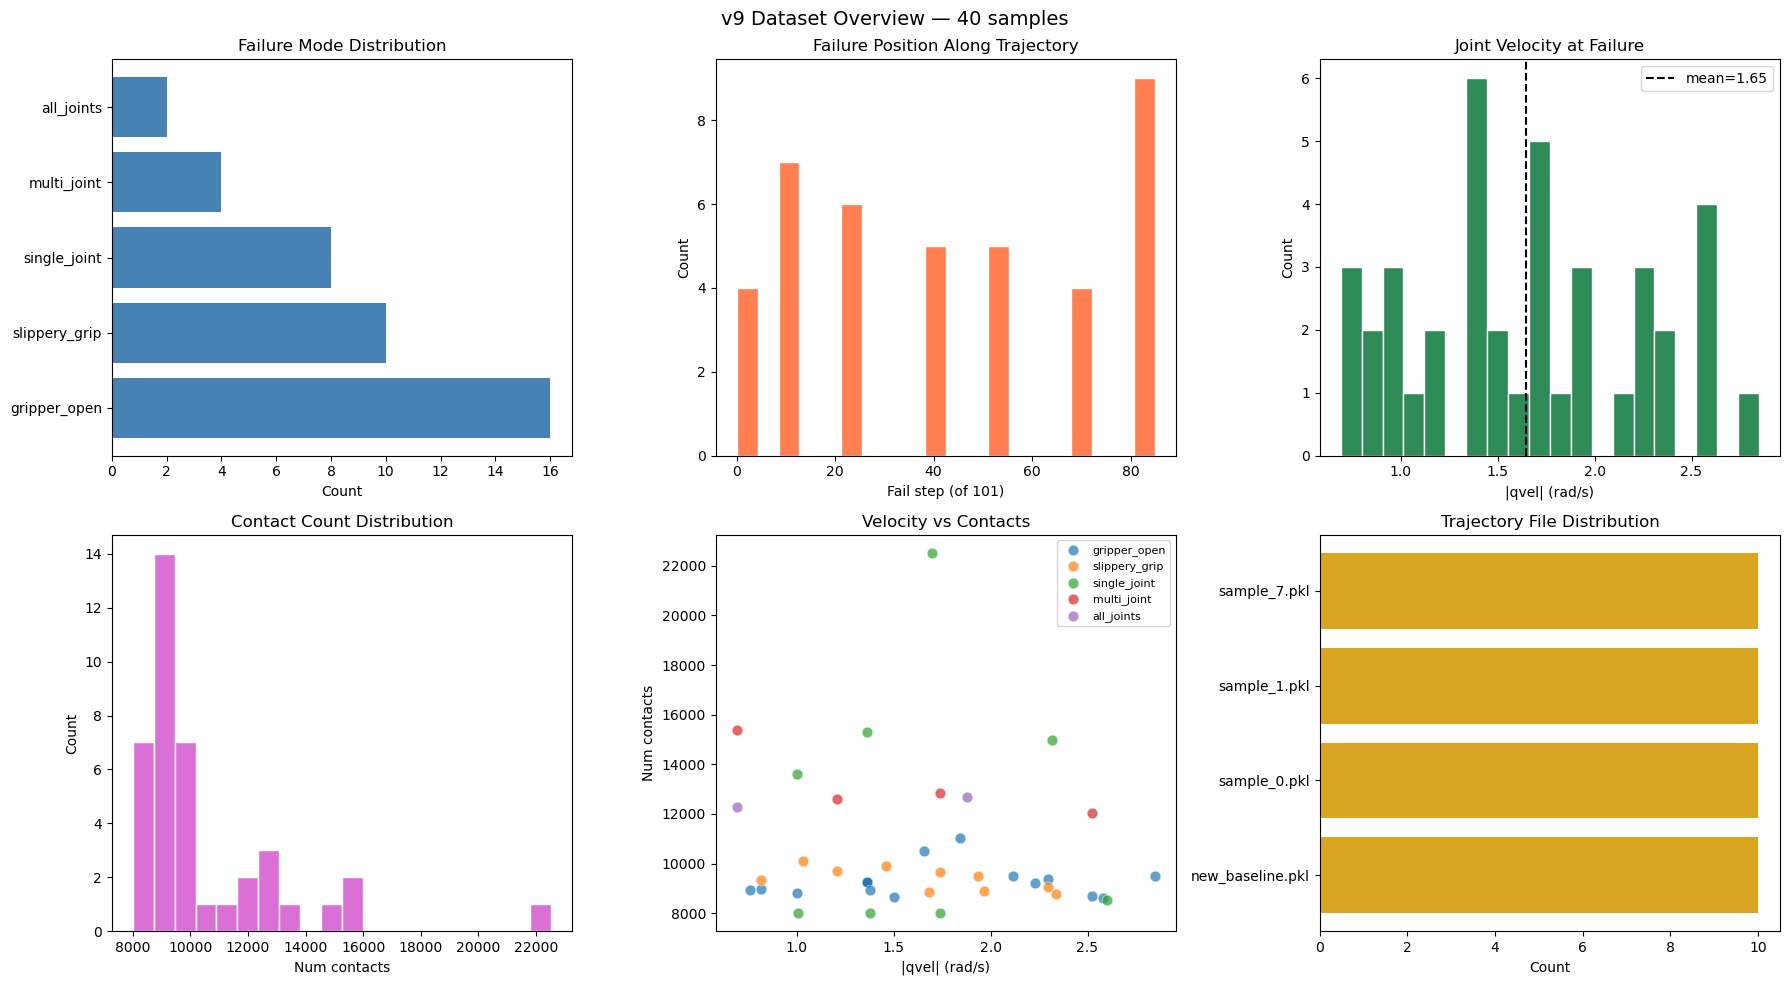

In [8]:
# Extract per-sample metadata
modes = [str(s['failure_modes'][0]) for s in samples]
qvel_norms = [float(s['pre_qvel_norm'][0]) for s in samples]
fail_steps = [int(s['fail_step'][0]) for s in samples]
contact_counts = [len(s['contact_positions']) for s in samples]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Failure mode distribution
mode_counts = pd.Series(modes).value_counts()
axes[0, 0].barh(mode_counts.index, mode_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_title('Failure Mode Distribution')

# Failure step (trajectory fraction) distribution
axes[0, 1].hist(fail_steps, bins=20, color='coral', edgecolor='white')
axes[0, 1].set_xlabel('Fail step (of 101)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Failure Position Along Trajectory')

# Velocity distribution
axes[0, 2].hist(qvel_norms, bins=20, color='seagreen', edgecolor='white')
axes[0, 2].set_xlabel('|qvel| (rad/s)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Joint Velocity at Failure')
axes[0, 2].axvline(np.mean(qvel_norms), color='k', ls='--',
                   label=f'mean={np.mean(qvel_norms):.2f}')
axes[0, 2].legend()

# Contact count distribution
axes[1, 0].hist(contact_counts, bins=20, color='orchid', edgecolor='white')
axes[1, 0].set_xlabel('Num contacts')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Contact Count Distribution')

# Velocity vs contact count
colors_mode = {m: c for m, c in zip(mode_counts.index,
               plt.cm.tab10(np.linspace(0, 1, len(mode_counts))))}
for m in mode_counts.index:
    mask = [modes[i] == m for i in range(len(modes))]
    axes[1, 1].scatter(
        np.array(qvel_norms)[mask], np.array(contact_counts)[mask],
        label=m, alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
axes[1, 1].set_xlabel('|qvel| (rad/s)')
axes[1, 1].set_ylabel('Num contacts')
axes[1, 1].set_title('Velocity vs Contacts')
axes[1, 1].legend(fontsize=8)

# Trajectory file distribution
traj_counts = manifest['trajectory_file'].value_counts()
axes[1, 2].barh(traj_counts.index.str.replace('scene_level2_RRTConnect_', ''),
                traj_counts.values, color='goldenrod')
axes[1, 2].set_xlabel('Count')
axes[1, 2].set_title('Trajectory File Distribution')

plt.suptitle(f'v9 Dataset Overview — {len(samples)} samples', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Sample Grid

Front camera pre-failure RGB for 16 samples, grouped by failure mode.

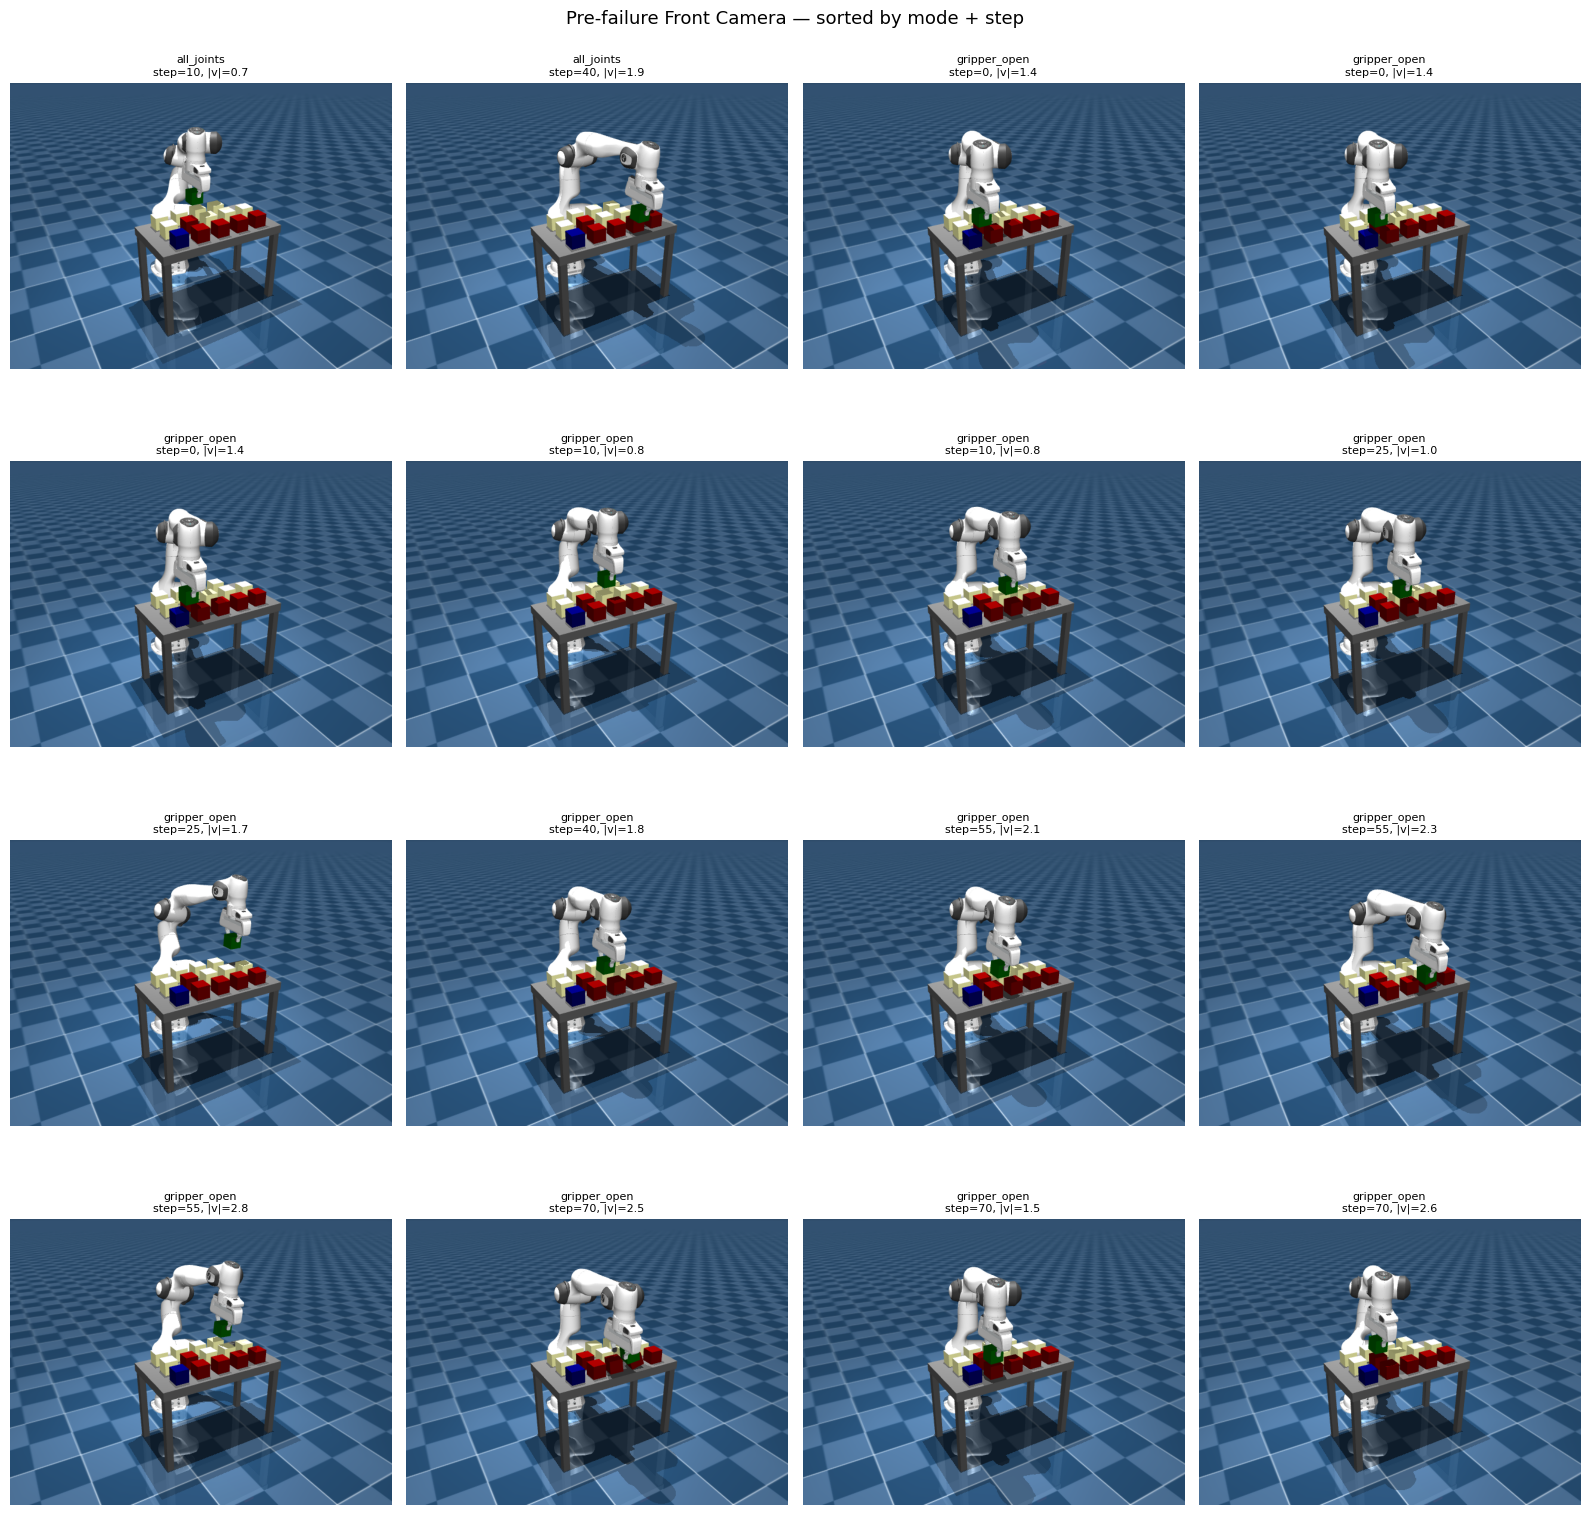

In [9]:
n_show = min(16, len(samples))
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# Sort by failure mode then step for visual grouping
order = sorted(range(len(samples)),
               key=lambda i: (modes[i], fail_steps[i]))

for j in range(n_show):
    i = order[j]
    ax = axes[j // 4, j % 4]
    ax.imshow(samples[i]['pre_rgb'])
    ax.set_title(f"{modes[i]}\nstep={fail_steps[i]}, |v|={qvel_norms[i]:.1f}",
                 fontsize=8)
    ax.axis('off')

for j in range(n_show, 16):
    axes[j // 4, j % 4].axis('off')

plt.suptitle('Pre-failure Front Camera — sorted by mode + step', fontsize=13)
plt.tight_layout()
plt.show()

## 7. EE Camera Grid

Compare EE camera views across different failure positions.

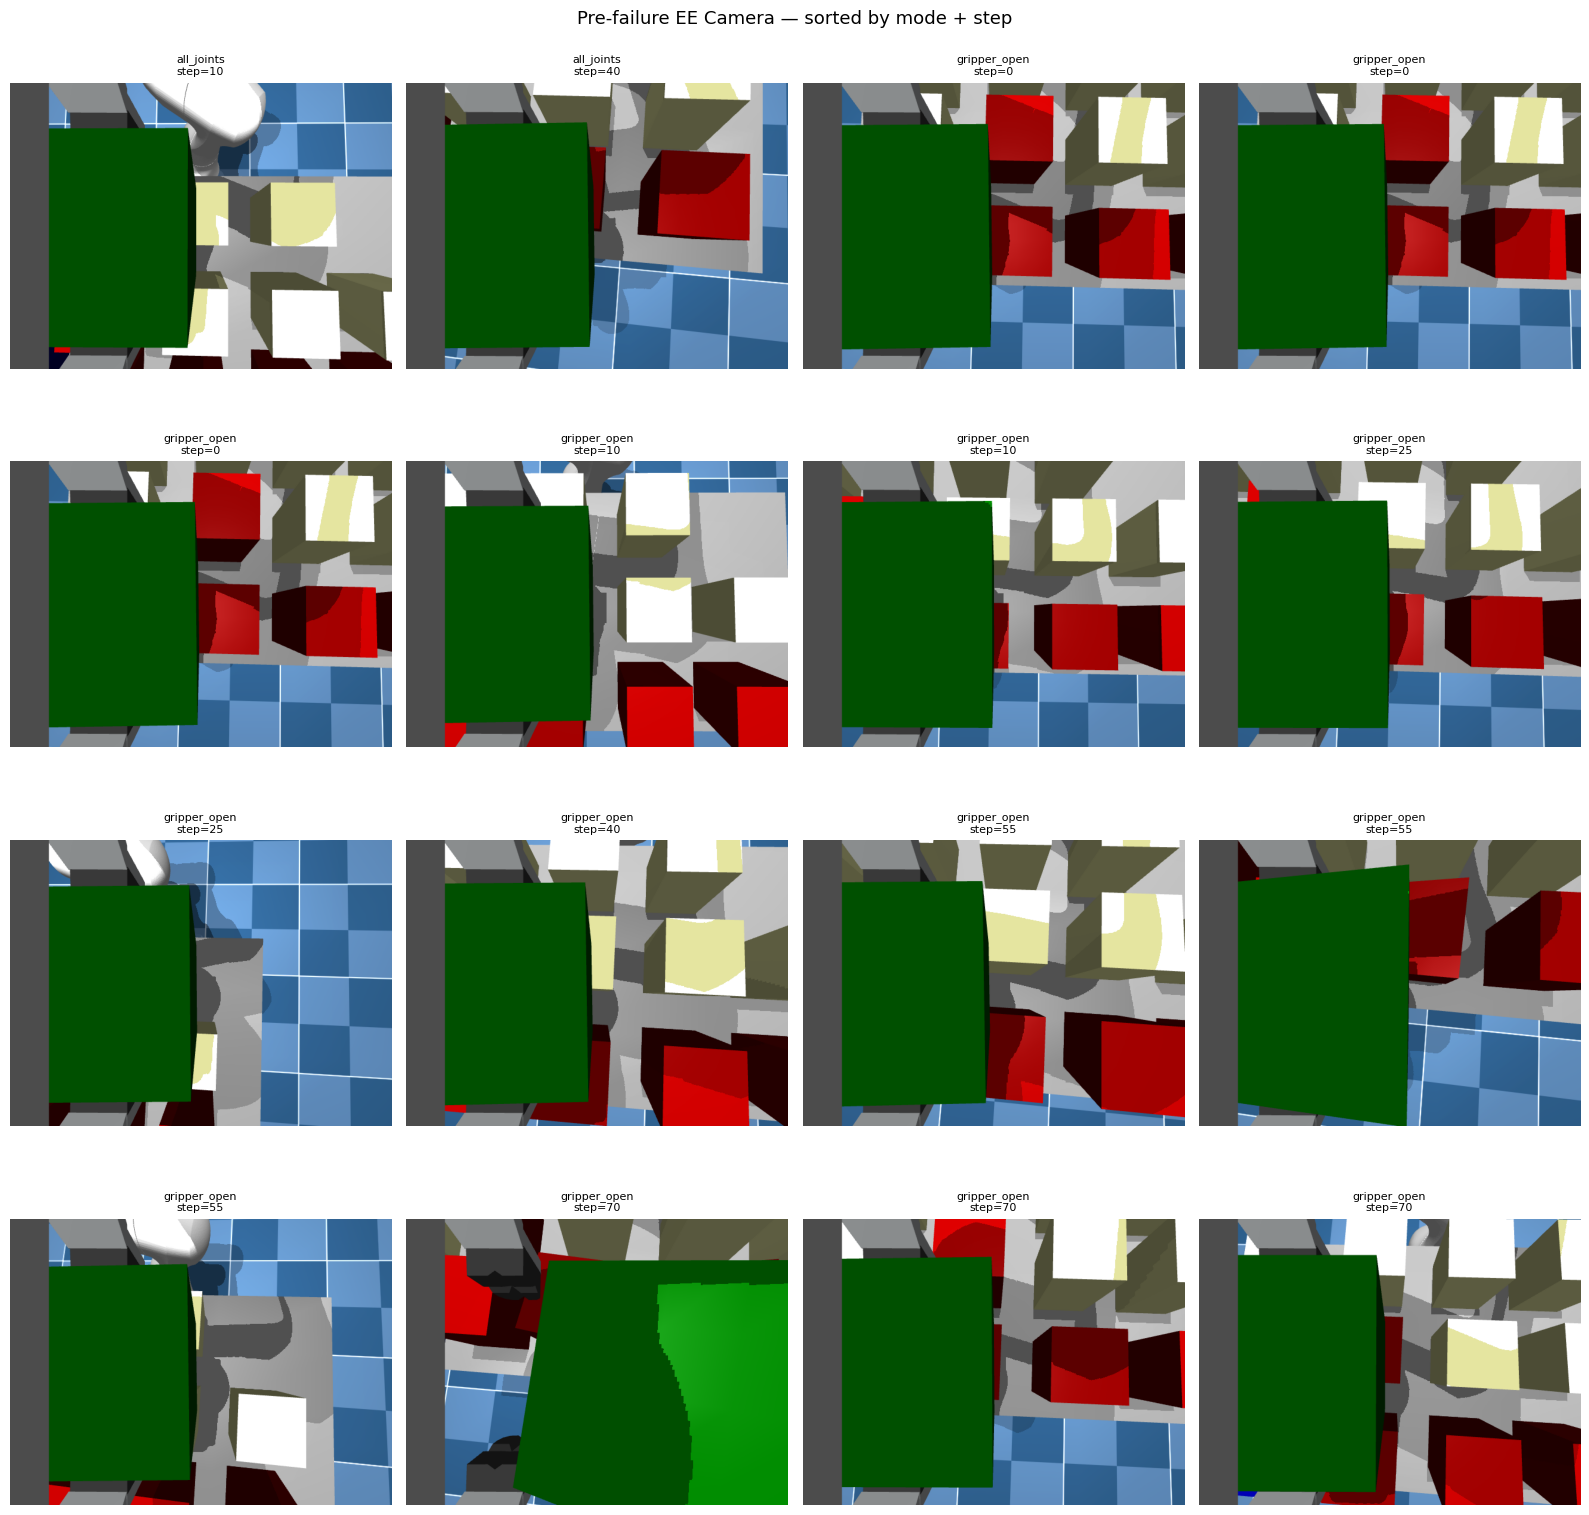

In [10]:
n_show = min(16, len(samples))
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for j in range(n_show):
    i = order[j]
    ax = axes[j // 4, j % 4]
    ax.imshow(samples[i]['ee_cam_rgb'])
    ax.set_title(f"{modes[i]}\nstep={fail_steps[i]}", fontsize=8)
    ax.axis('off')

for j in range(n_show, 16):
    axes[j // 4, j % 4].axis('off')

plt.suptitle('Pre-failure EE Camera — sorted by mode + step', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Contact Projection Across Samples

Overlay contacts on pre-failure RGB for several diverse samples.

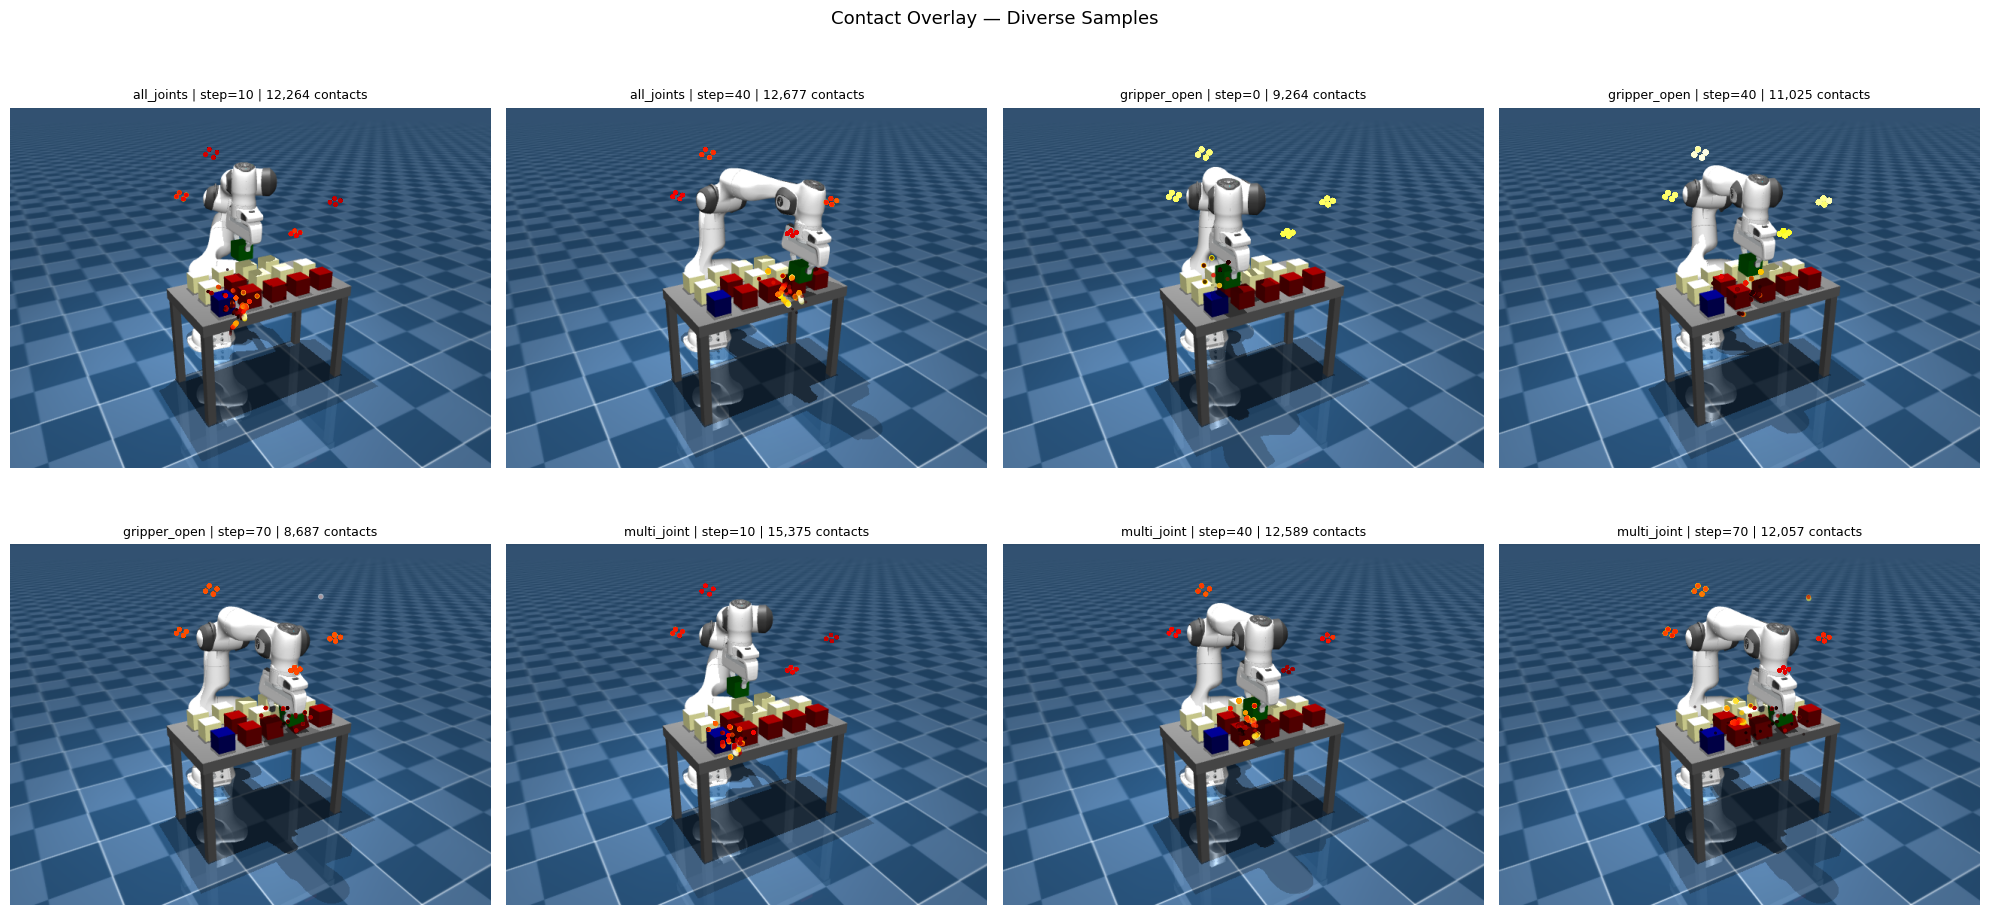

In [ ]:
# Pick 8 diverse samples: different modes and steps
diverse_idx = []
seen_modes = set()
for i in order:
    key = (modes[i], fail_steps[i] // 30)  # bin steps coarsely
    if key not in seen_modes:
        diverse_idx.append(i)
        seen_modes.add(key)
    if len(diverse_idx) >= 8:
        break

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for j, i in enumerate(diverse_idx):
    ax = axes[j // 4, j % 4]
    ax.imshow(samples[i]['pre_rgb'])

    p = samples[i]['contact_positions']
    f = np.linalg.norm(samples[i]['contact_forces'][:, :3], axis=1)
    fl = np.log1p(f)

    px_i, d_i = projector.project(p)
    mask = projector.in_frame(px_i, d_i)
    vp, vf = px_i[mask], fl[mask]

    if len(vp) > 2000:
        sub = rng.choice(len(vp), 2000, replace=False)
        vp, vf = vp[sub], vf[sub]

    if len(vp) > 0:
        fn = vf / max(vf.max(), 1)
        ax.scatter(vp[:, 0], vp[:, 1], c=fn, cmap='hot',
                   s=2 + fn * 15, alpha=0.5, edgecolors='none')

    ax.set_xlim(0, 640); ax.set_ylim(480, 0)
    ax.set_title(f"{modes[i]} | step={fail_steps[i]} | {len(p):,} contacts",
                 fontsize=9)
    ax.axis('off')

for j in range(len(diverse_idx), 8):
    axes[j // 4, j % 4].axis('off')

plt.suptitle('Contact Overlay — Diverse Samples', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Robot State at Failure

Joint positions and velocities across the dataset.

/tmp/ipykernel_1979899/3272958599.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot([all_qpos[:, j] for j in range(7)],
/tmp/ipykernel_1979899/3272958599.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot([all_qvel[:, j] for j in range(7)],


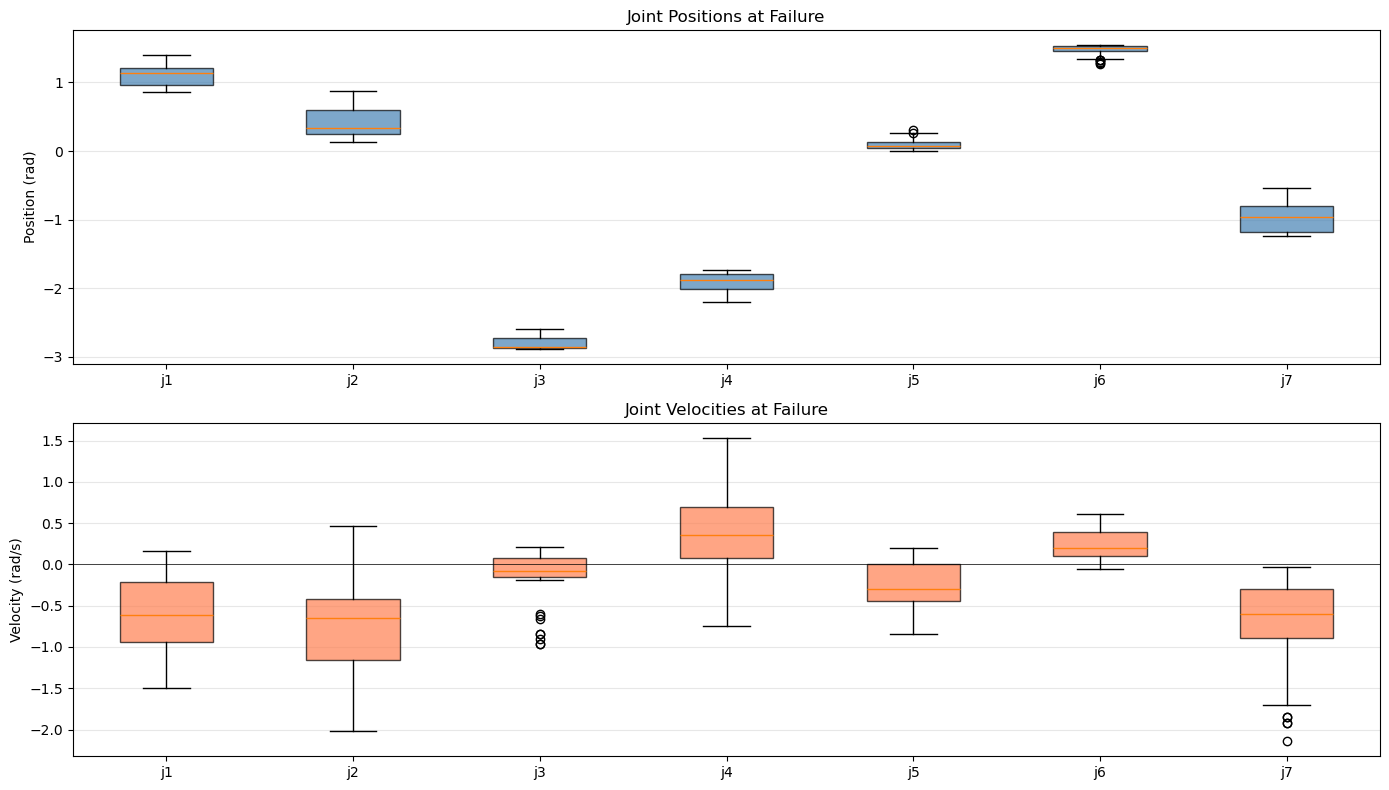

In [12]:
all_qpos = np.array([s['pre_qpos'] for s in samples])
all_qvel = np.array([s['pre_qvel'] for s in samples])
joint_names = [f'j{i+1}' for i in range(7)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Joint positions
bp1 = axes[0].boxplot([all_qpos[:, j] for j in range(7)],
                       labels=joint_names, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
axes[0].set_ylabel('Position (rad)')
axes[0].set_title('Joint Positions at Failure')
axes[0].grid(axis='y', alpha=0.3)

# Joint velocities
bp2 = axes[1].boxplot([all_qvel[:, j] for j in range(7)],
                       labels=joint_names, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)
axes[1].set_ylabel('Velocity (rad/s)')
axes[1].set_title('Joint Velocities at Failure')
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## 10. Summary Table

In [13]:
summary = manifest.copy()
summary['failure_mode'] = modes
summary['qvel_norm'] = qvel_norms

print("=== Per Failure Mode ===")
print(summary.groupby('failure_mode').agg(
    count=('experiment_id', 'count'),
    mean_contacts=('num_contacts', 'mean'),
    mean_qvel=('qvel_norm', 'mean'),
    collision_rate=('had_any_collision', 'mean'),
).round(2).to_string())

print("\n=== Per Trajectory ===")
print(summary.groupby('trajectory_file').agg(
    count=('experiment_id', 'count'),
    mean_contacts=('num_contacts', 'mean'),
    mean_qvel=('qvel_norm', 'mean'),
).round(2).to_string())

print(f"\n=== Overall ===")
print(f"Total samples: {len(manifest)}")
print(f"Total contacts: {manifest['num_contacts'].sum():,}")
print(f"Collision rate: {manifest['had_any_collision'].mean():.1%}")
print(f"Mean |qvel|: {np.mean(qvel_norms):.2f} rad/s")
print(f"Unique failure modes: {len(set(modes))}")
print(f"Failure step range: {min(fail_steps)} — {max(fail_steps)}")

=== Per Failure Mode ===
               count  mean_contacts  mean_qvel  collision_rate
failure_mode                                                  
all_joints         2       12470.50       1.28             1.0
gripper_open      16        9283.62       1.73             1.0
multi_joint        4       13212.25       1.54             1.0
single_joint       8       12370.50       1.64             1.0
slippery_grip     10        9373.20       1.65             1.0

=== Per Trajectory ===
                                          count  mean_contacts  mean_qvel
trajectory_file                                                          
scene_level2_RRTConnect_new_baseline.pkl     10        10067.8       1.44
scene_level2_RRTConnect_sample_0.pkl         10        10116.0       2.01
scene_level2_RRTConnect_sample_1.pkl         10         9764.9       1.30
scene_level2_RRTConnect_sample_7.pkl         10        11953.7       1.83

=== Overall ===
Total samples: 40
Total contacts: 419,024
Collisi